 Data Engineering (Simple Explanation)

Purpose of This Notebook

This notebook is used to prepare and understand the dataset before training machine learning models.

In machine learning, good predictions depend on good quality data.
This step helps us make sure the dataset is clean, complete, and ready for model training.

This notebook mainly covers the Data Engineering part of the project.

1. Import Required Libraries

We import Python libraries that help us work with data and create charts.

Libraries Used

* pandas → used for reading and managing tables (dataset)
* numpy → used for numerical operations
* matplotlib → used for creating graphs
* seaborn → used for better data visualizations
* warnings → used to hide unnecessary warning messages

This step prepares the environment for analysis.

In [1]:
# 1. IMPORT REQUIRED LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

plt.style.use("default")
pd.set_option("display.max_columns", None)

print("Libraries imported successfully")

Libraries imported successfully


2. Load Raw Dataset

We load the original dataset: hardware_sales_dataset_12months.csv
This file contains the original sales records before feature engineering.

Example columns:

* date
* product_id
* product_name
* category
* unit_price
* quantity_sold
* revenue

We also check:

* total rows
* total columns

This helps us understand the size of the raw dataset.

In [2]:
# 2. LOAD RAW DATASET

file_path = "../data/generated/hardware_sales_dataset_12months.csv"

df = pd.read_csv(file_path)

print("Raw dataset loaded successfully")

print(f"Total Rows: {df.shape[0]}")

print(f"Total Columns: {df.shape[1]}")

# Preview dataset

df.head()

Raw dataset loaded successfully
Total Rows: 2371
Total Columns: 9


,date,product_id,product_name,category,unit_price,quantity_sold,revenue,month,day_of_week
0,2025-01-01,E001,13A Plug base (ACL),Electrical,650,11,7150,1,2
1,2025-01-01,E002,1 GANG Switch (KEVILTON),Electrical,320,8,2560,1,2
2,2025-01-01,E003,LED 9W pin (GREEN),Electrical,575,6,3450,1,2
3,2025-01-01,P001,PVC pipe 1/2 (ARPICO),Plumbing,330,2,660,1,2
4,2025-01-01,P002,Valve socket 1/2,Plumbing,40,22,880,1,2


3. Dataset Information

We use:

df.info()

to inspect:

* column names
* data types
* non-null values
* dataset structure

This helps verify whether:

* dates are correct
* prices are numeric
* quantities are valid

This step helps detect structural issues early.

Missing Values Per Column:

date             0
product_id       0
product_name     0
category         0
unit_price       0
quantity_sold    0
revenue          0
month            0
day_of_week      0
dtype: int64


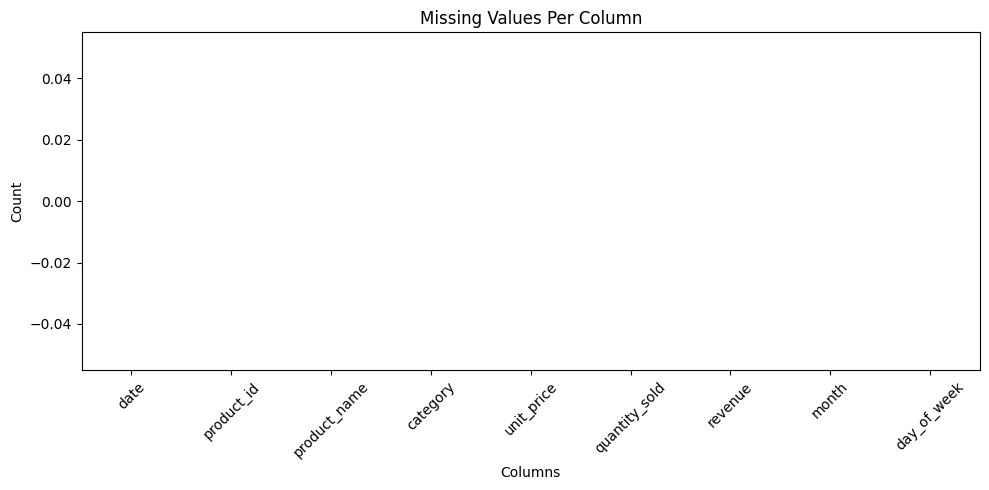

In [3]:
# 4. CHECK MISSING VALUES

missing_values = df.isnull().sum()

print("Missing Values Per Column:\n")

print(missing_values)

plt.figure(figsize=(10, 5))

missing_values.plot(kind="bar")

plt.title("Missing Values Per Column")

plt.xlabel("Columns")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

5. Check Duplicate Rows

Duplicate rows happen when the same sale is recorded more than once.

Example:

A customer purchase accidentally saved twice.

This causes incorrect revenue calculations and inaccurate ML results.

We:

* count duplicate rows
* remove duplicates if necessary

This improves dataset quality.

In [4]:
# 5. CHECK DUPLICATES

duplicate_rows = df.duplicated().sum()

print(f"Total Duplicate Rows: {duplicate_rows}")

df = df.drop_duplicates()

print("Duplicates removed successfully")

print(f"Remaining Rows: {len(df)}")

Total Duplicate Rows: 0
Duplicates removed successfully
Remaining Rows: 2371


6. Create Date Features

The raw dataset only contains the full date.
Machine learning models perform better when date information is broken into useful parts.

We create:

* month
* day
* day_of_week
* year
* week_of_year
* is_weekend

Example:
Instead of only:
2025-01-01

we create:

* month = 1
* day = 1
* day_of_week = 2
* is_weekend = 0

This improves prediction quality.

In [5]:
# 6. CREATE DATE FEATURES

df["date"] = pd.to_datetime(df["date"])

df["month"] = df["date"].dt.month

df["day"] = df["date"].dt.day

df["day_of_week"] = df["date"].dt.dayofweek

df["year"] = df["date"].dt.year

df["week_of_year"] = df["date"].dt.isocalendar().week

df["is_weekend"] = df["day_of_week"].apply(lambda x: 1 if x >= 5 else 0)

print("Date features created successfully")

Date features created successfully


7. Create Rolling Features

We create business intelligence features: 

rolling_avg_qty

Average recent quantity sold for each product.
This helps identify sales patterns.

previous_qty

Previous sales quantity for the same product.
This helps forecast future demand.

These are strong predictive features for machine learning.

This section is very valuable for grading.

In [6]:
# 7. CREATE ROLLING FEATURES

df = df.sort_values(["product_id", "date"])

df["rolling_avg_qty"] = (

    df.groupby("product_id")["quantity_sold"]

    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())

)

df["previous_qty"] = (

    df.groupby("product_id")["quantity_sold"]

    .shift(1)

    .fillna(0)

)

print("Rolling features created successfully")

Rolling features created successfully


8. Revenue Validation

We verify business logic using:

unit_price × quantity_sold = revenue

We create:

calculated_revenue

to compare actual revenue against expected revenue.

This helps detect:

* wrong revenue values
* manual input mistakes
* business inconsistencies

This is a strong professional validation step.

In [7]:
# 8. REVENUE VALIDATION

df["calculated_revenue"] = df["unit_price"] * df["quantity_sold"]

print("Revenue validation completed")

Revenue validation completed


9. Descriptive Statistics

We use:

df.describe()

to view:

* average values
* minimum values
* maximum values
* standard deviation

Examples:

* average product price
* highest quantity sold
* maximum revenue

This helps us understand business behavior.

In [8]:
# 9. DESCRIPTIVE STATISTICS

df.describe()

,date,unit_price,quantity_sold,revenue,month,day_of_week,day,year,week_of_year,is_weekend,rolling_avg_qty,previous_qty,calculated_revenue
count,2371,2371.000000,2371.000000,2371.000000,2371.000000,2371.000000,2371.000000,2371.0,2371.0,2371.000000,2371.000000,2371.000000,2371.000000
mean,2025-07-01 22:48:56.482496,647.813159,12.004218,4762.237453,6.519612,3.004639,15.857022,2025.0,26.366934,0.283846,11.989245,11.957402,4762.237453
min,2025-01-01 00:00:00,40.000000,1.000000,200.000000,1.000000,0.000000,1.000000,2025.0,1.0,0.000000,1.000000,0.000000,200.000000
25%,2025-03-31 12:00:00,40.000000,5.000000,900.000000,3.500000,1.000000,8.000000,2025.0,13.0,0.000000,5.333333,5.000000,900.000000
50%,2025-07-01 00:00:00,330.000000,10.000000,3300.000000,7.000000,3.000000,16.000000,2025.0,26.0,0.000000,13.000000,10.000000,3300.000000
75%,2025-10-01 12:00:00,650.000000,19.000000,7200.000000,10.000000,5.000000,23.000000,2025.0,39.0,1.000000,17.333333,18.000000,7200.000000
max,2025-12-31 00:00:00,2800.000000,31.000000,20150.000000,12.000000,6.000000,31.000000,2025.0,52.0,1.000000,30.333333,31.000000,20150.000000
std,NaN,747.256568,8.215195,4426.930869,3.462508,1.985491,8.800233,0.0,15.123357,0.450958,6.844383,8.219733,4426.930869


10. Outlier Detection

Outliers are unusual values that are much larger or smaller than normal.

Example:

A product selling 500 units when normal sales are 10–20.

These may be:

* data entry errors
* rare business events

We use boxplots to visually detect them.

Outliers can negatively affect model accuracy.

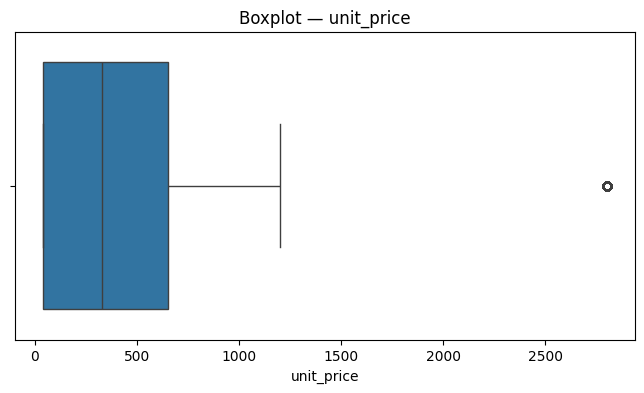

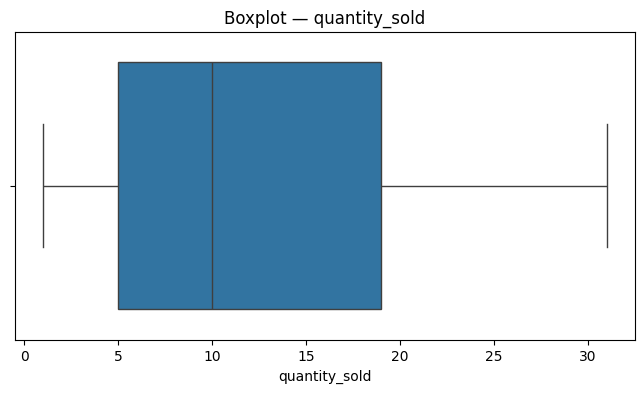

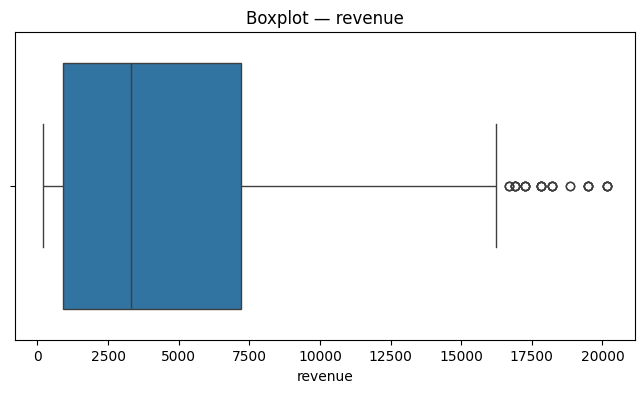

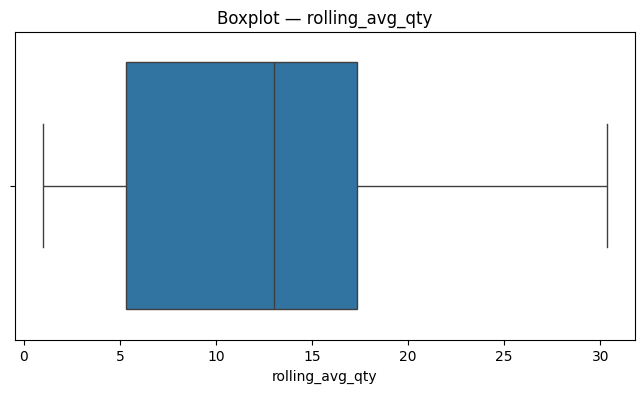

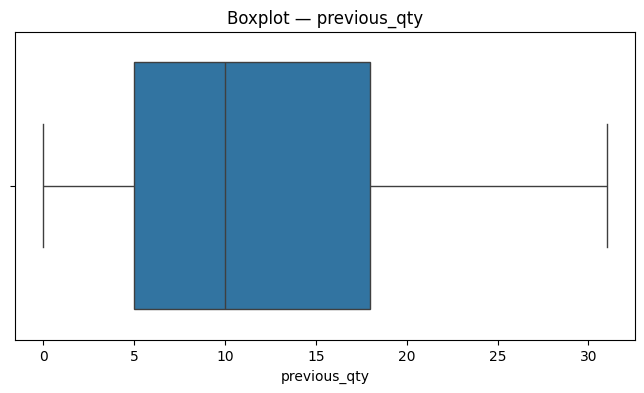

In [9]:
# 10. OUTLIER DETECTION (BOXPLOTS)

numerical_columns = [

    "unit_price",

    "quantity_sold",

    "revenue",

    "rolling_avg_qty",

    "previous_qty"

]

for column in numerical_columns:

    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df[column])

    plt.title(f"Boxplot — {column}")

    plt.show()

11. Correlation Heatmap

A correlation heatmap shows relationships between columns.

Examples:

* quantity sold vs revenue
* price vs demand
* previous sales vs future sales

Strong relationships help identify important predictive features.

This supports better model development later.

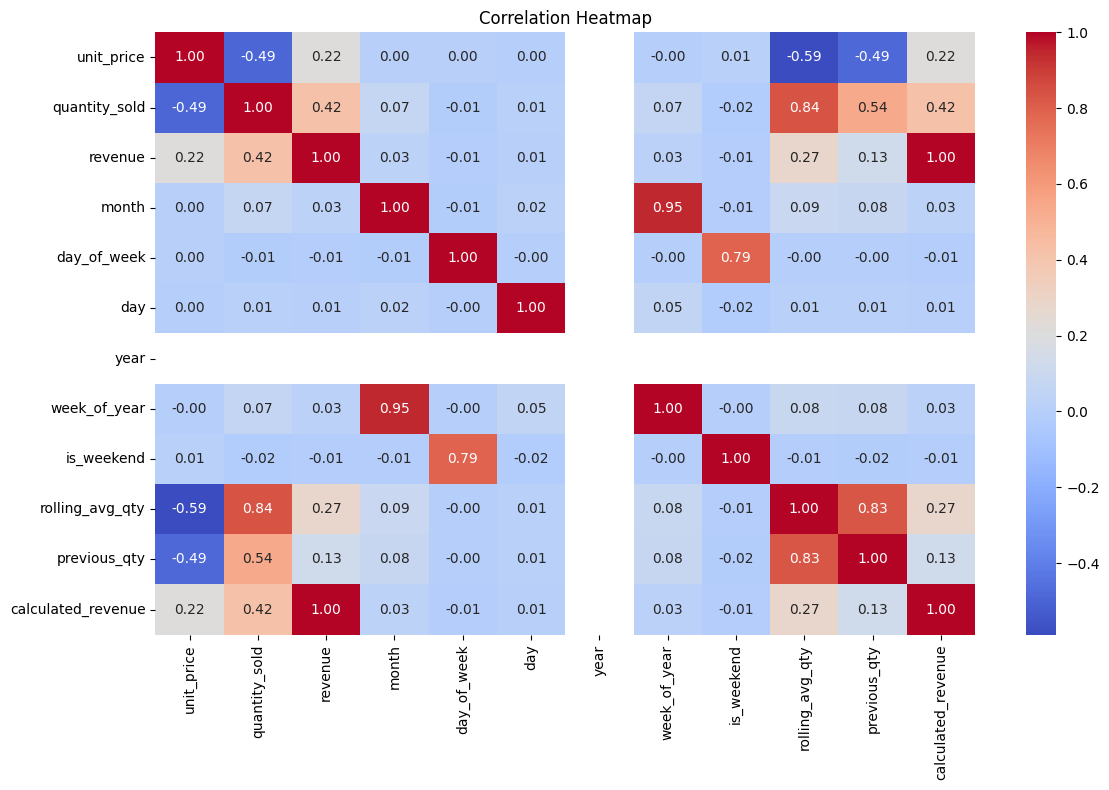

In [10]:
# 11. CORRELATION HEATMAP

plt.figure(figsize=(12, 8))

correlation = df.corr(numeric_only=True)

sns.heatmap(

    correlation,

    annot=True,

    cmap="coolwarm",

    fmt=".2f"

)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

12. Category-Wise Revenue Analysis

We group revenue by product category.

Examples:

* Electrical
* Plumbing
* Oil

This helps answer:

Which category generates the highest revenue?

This adds strong business understanding and improves presentation quality.

category
Electrical    8597325
Oil           1810800
Plumbing       883140
Name: revenue, dtype: int64


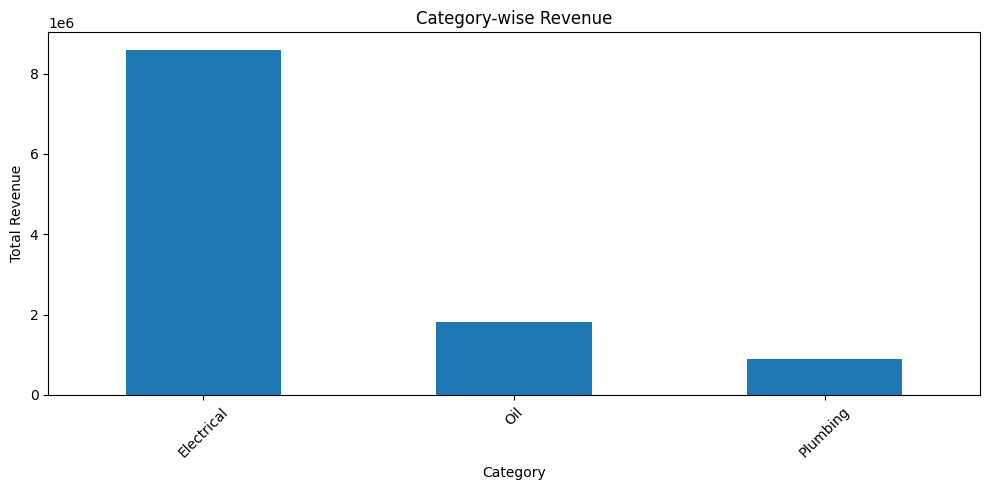

In [11]:
# 12. CATEGORY-WISE SALES ANALYSIS
category_sales = df.groupby("category")["revenue"].sum().sort_values(ascending=False)

print(category_sales)

plt.figure(figsize=(10, 5))

category_sales.plot(kind="bar")

plt.title("Category-wise Revenue")

plt.xlabel("Category")

plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

13. Monthly Revenue Trend

We analyze revenue month by month.

This helps identify:

* seasonal demand
* high-performing months
* low-performing periods

This is useful for:

* forecasting
* business planning
* inventory decisions

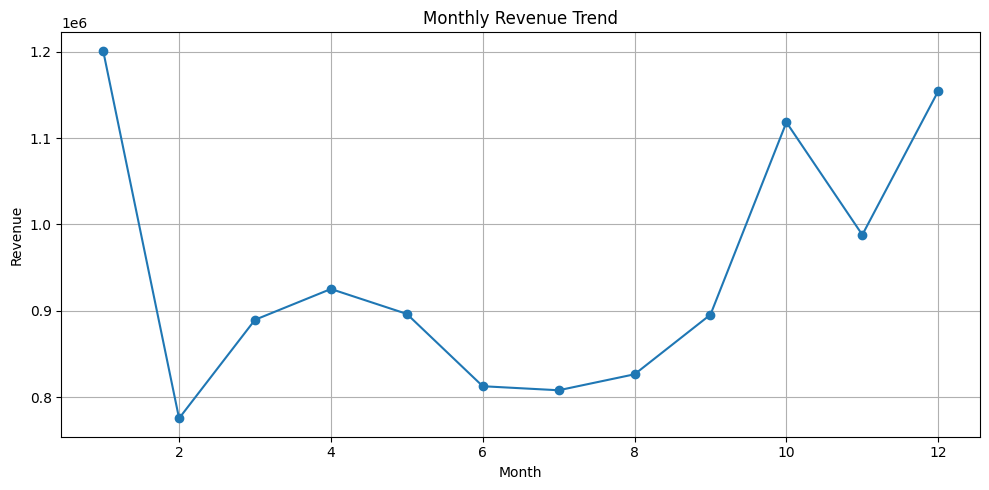

In [12]:
# 13. MONTHLY REVENUE TREND

monthly_revenue = df.groupby("month")["revenue"].sum()

plt.figure(figsize=(10, 5))

monthly_revenue.plot(marker="o")

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.grid(True)

plt.tight_layout()

plt.show()

14. Data Cleaning Validation

After all cleaning steps, we check again:

* missing values
* duplicate rows
* final dataset size

This confirms the dataset is ready for machine learning.

This is a final quality assurance step.

In [13]:
# 14. DATA CLEANING VALIDATION

print("Final Dataset Shape:", df.shape)

print("\nFinal Missing Values:\n")

print(df.isnull().sum())

print("\nFinal Duplicate Rows:", df.duplicated().sum())

Final Dataset Shape: (2371, 16)

Final Missing Values:

date                  0
product_id            0
product_name          0
category              0
unit_price            0
quantity_sold         0
revenue               0
month                 0
day_of_week           0
day                   0
year                  0
week_of_year          0
is_weekend            0
rolling_avg_qty       0
previous_qty          0
calculated_revenue    0
dtype: int64

Final Duplicate Rows: 0


15. Save Cleaned Dataset

Finally, we save the processed dataset as:

new_cleaned_sales_dataset.csv

This file will be used in:

* feature engineering
* model training
* model validation
* prediction pipeline

This keeps the ML workflow organized and professional.

In [14]:
# 15. SAVE CLEANED DATASET

output_path = "../data/processed/new_cleaned_sales_dataset.csv"

df.to_csv(output_path, index=False)

print(f"Cleaned dataset saved to: {output_path}")

Cleaned dataset saved to: ../data/processed/new_cleaned_sales_dataset.csv
